# Evaluation Results Summary

This notebook loads `data/evaluation_results.json`, summarizes overall metrics, and visualizes per-query behavior.

In [2]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt

RESULTS_PATH = Path("../data/evaluation_results.json")

if not RESULTS_PATH.exists():
    raise FileNotFoundError(f"Missing results file: {RESULTS_PATH.resolve()}")

with RESULTS_PATH.open("r", encoding="utf-8") as f:
    data = json.load(f)

data.keys()

dict_keys(['model', 'metrics', 'results'])

In [3]:
metrics = data.get("metrics", {})
model_info = data.get("model", {})

summary_df = pd.DataFrame([
    {
        "model_name": model_info.get("model_name"),
        "pretrained": model_info.get("pretrained"),
        "num_queries": metrics.get("num_queries"),
        "recall@1": metrics.get("recall@1"),
        "recall@5": metrics.get("recall@5"),
        "mrr": metrics.get("mrr"),
    }
])

summary_df

,model_name,pretrained,num_queries,recall@1,recall@5,mrr
0,ViT-B-32,laion2b_s34b_b79k,117,0.820513,0.940171,0.867719


In [4]:
results = data.get("results", [])
if not results:
    raise ValueError("No per-query results found in evaluation_results.json")

rows = []
for r in results:
    rows.append({
        "query_index": r.get("query_index"),
        "query": r.get("query"),
        "source_query": r.get("source_query"),
        "best_rank": r.get("best_rank"),
        "hit@1": r.get("hit@1"),
        "hit@5": r.get("hit@5"),
        "reciprocal_rank": r.get("reciprocal_rank"),
    })

per_query_df = pd.DataFrame(rows)
per_query_df.head()

,query_index,query,source_query,best_rank,hit@1,hit@5,reciprocal_rank
0,1,book and reading,book and reading,1,True,True,1.000000
1,2,book illustration search and reading concept art,book illustration search and reading concept art,3,False,True,0.333333
2,3,person facing a giant open handwritten book on...,A person faces a giant open book with handwrit...,1,True,True,1.000000
3,4,prison bars,prison and bars,1,True,True,1.000000
4,5,prison image search and human portrait illustr...,prison image search and human portrait illustr...,1,True,True,1.000000


In [5]:
# Basic counts
num_queries = len(per_query_df)
misses = per_query_df[per_query_df["best_rank"].isna()]

print(f"Total queries: {num_queries}")
print(f"Misses (no relevant result found): {len(misses)}")
print(f"Hit rate: {1 - len(misses)/num_queries:.2%}")

Total queries: 117
Misses (no relevant result found): 0
Hit rate: 100.00%


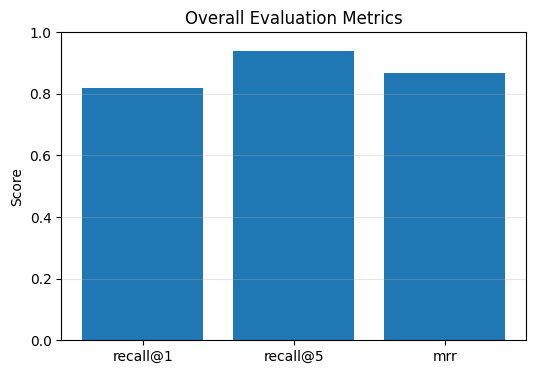

In [6]:
# Metrics bar plot
plt.figure(figsize=(6, 4))
plt.bar(["recall@1", "recall@5", "mrr"], [
    metrics.get("recall@1", 0),
    metrics.get("recall@5", 0),
    metrics.get("mrr", 0),
])
plt.ylim(0, 1.0)
plt.title("Overall Evaluation Metrics")
plt.ylabel("Score")
plt.grid(axis="y", alpha=0.3)
plt.show()

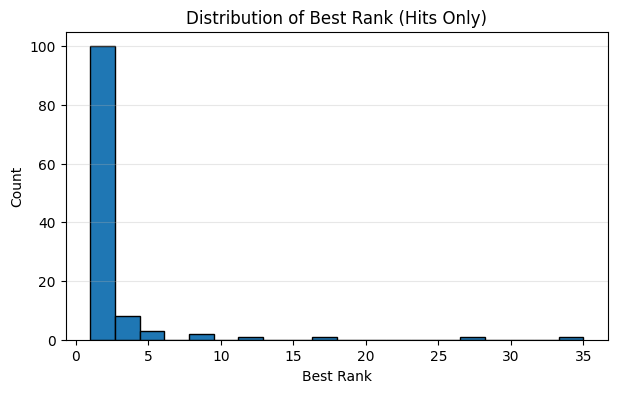

In [7]:
# Best-rank histogram (ignoring misses)
ranked = per_query_df.dropna(subset=["best_rank"]).copy()

plt.figure(figsize=(7, 4))
plt.hist(ranked["best_rank"], bins=20, edgecolor="black")
plt.title("Distribution of Best Rank (Hits Only)")
plt.xlabel("Best Rank")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)
plt.show()

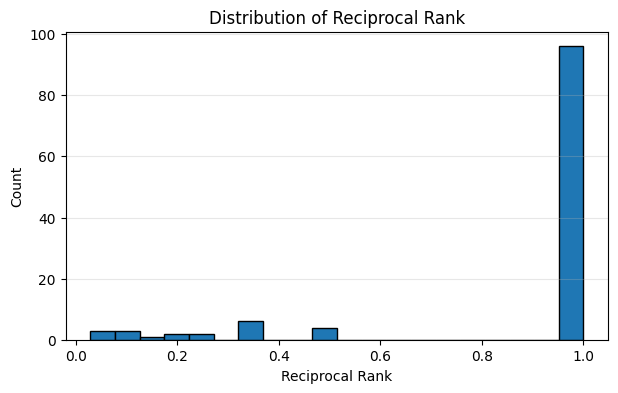

In [8]:
# Reciprocal rank distribution
plt.figure(figsize=(7, 4))
plt.hist(per_query_df["reciprocal_rank"], bins=20, edgecolor="black")
plt.title("Distribution of Reciprocal Rank")
plt.xlabel("Reciprocal Rank")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [9]:
# Worst-performing queries (misses or large ranks)
worst = per_query_df.copy()
worst["best_rank_sort"] = worst["best_rank"].fillna(10**9)
worst = worst.sort_values(["best_rank_sort", "query_index"], ascending=[False, True])

worst[["query_index", "query", "source_query", "best_rank", "hit@1", "hit@5", "reciprocal_rank"]].head(20)

,query_index,query,source_query,best_rank,hit@1,hit@5,reciprocal_rank
85,86,"editorial control, theme, psychology, and mani...",editorial control theme and psychology and man...,35,False,False,0.028571
43,44,surreal illustration with emotions and concept...,surreal illustration search and emotions conce...,28,False,False,0.035714
82,83,business concept search and decision-making theme,business concept search and decision-making theme,17,False,False,0.058824
108,109,man with smartphone,man and smartphone,12,False,False,0.083333
100,101,lonely figure with dramatic lighting,lonely figure and dramatic lighting,8,False,False,0.125000
111,112,silhouettes and a man,silhouettes and man,8,False,False,0.125000
99,100,man and silhouette,man and silhouette,6,False,False,0.166667
101,102,lone man in a dark room lit by a narrow beam o...,A lone man stands in a dark room illuminated b...,5,False,True,0.200000
103,104,loneliness and leadership metaphor,loneliness concept and leadership metaphor,5,False,True,0.200000
54,55,illustration and walking,illustration and walking,4,False,True,0.250000
